In [1]:
import pandas as pd

dataset link: https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml?select=LI-Large_Trans.csv

In [2]:
df = pd.read_csv("/kaggle/input/ibm-transactions-for-anti-money-laundering-aml/LI-Small_Trans.csv")
df.head()

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:08,11,8000ECA90,11,8000ECA90,3195403.00,US Dollar,3195403.00,US Dollar,Reinvestment,0
1,2022/09/01 00:21,3402,80021DAD0,3402,80021DAD0,1858.96,US Dollar,1858.96,US Dollar,Reinvestment,0
2,2022/09/01 00:00,11,8000ECA90,1120,8006AA910,592571.00,US Dollar,592571.00,US Dollar,Cheque,0
3,2022/09/01 00:16,3814,8006AD080,3814,8006AD080,12.32,US Dollar,12.32,US Dollar,Reinvestment,0
4,2022/09/01 00:00,20,8006AD530,20,8006AD530,2941.56,US Dollar,2941.56,US Dollar,Reinvestment,0


In [3]:
df.isnull().sum()

Timestamp             0
From Bank             0
Account               0
To Bank               0
Account.1             0
Amount Received       0
Receiving Currency    0
Amount Paid           0
Payment Currency      0
Payment Format        0
Is Laundering         0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6924049 entries, 0 to 6924048
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           object 
 1   From Bank           int64  
 2   Account             object 
 3   To Bank             int64  
 4   Account.1           object 
 5   Amount Received     float64
 6   Receiving Currency  object 
 7   Amount Paid         float64
 8   Payment Currency    object 
 9   Payment Format      object 
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 581.1+ MB


In [6]:
df.nunique()

Timestamp               14533
From Bank               41814
Account                681281
To Bank                 21588
Account.1              576176
Amount Received       1194921
Receiving Currency         15
Amount Paid           1204309
Payment Currency           15
Payment Format              7
Is Laundering               2
dtype: int64

In [7]:
df.columns

Index(['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1',
       'Amount Received', 'Receiving Currency', 'Amount Paid',
       'Payment Currency', 'Payment Format', 'Is Laundering'],
      dtype='object')

In [8]:
df.describe()

,From Bank,To Bank,Amount Received,Amount Paid,Is Laundering
count,6.924049e+06,6.924049e+06,6.924049e+06,6.924049e+06,6.924049e+06
mean,5.938718e+04,8.441702e+04,6.324067e+06,4.676036e+06,5.148722e-04
std,9.051700e+04,9.064562e+04,2.105371e+09,1.544099e+09,2.268495e-02
min,0.000000e+00,0.000000e+00,1.000000e-06,1.000000e-06,0.000000e+00
25%,2.190000e+02,1.125500e+04,1.742100e+02,1.753800e+02,0.000000e+00
50%,1.419500e+04,2.964000e+04,1.397620e+03,1.399440e+03,0.000000e+00
75%,1.106820e+05,1.480400e+05,1.229633e+04,1.222687e+04,0.000000e+00
max,3.769670e+05,3.769670e+05,3.644854e+12,3.644854e+12,1.000000e+00


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

Distribution of Amounts

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


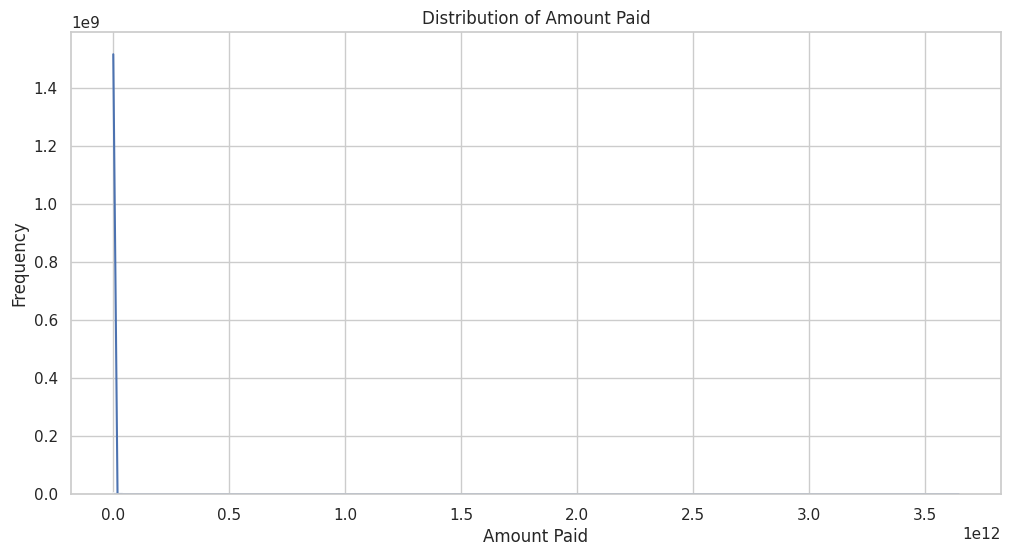

In [10]:
# Histogram of Amount Paid
sns.histplot(df['Amount Paid'], bins=100, kde=True)
plt.title('Distribution of Amount Paid')
plt.xlabel('Amount Paid')
plt.ylabel('Frequency')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


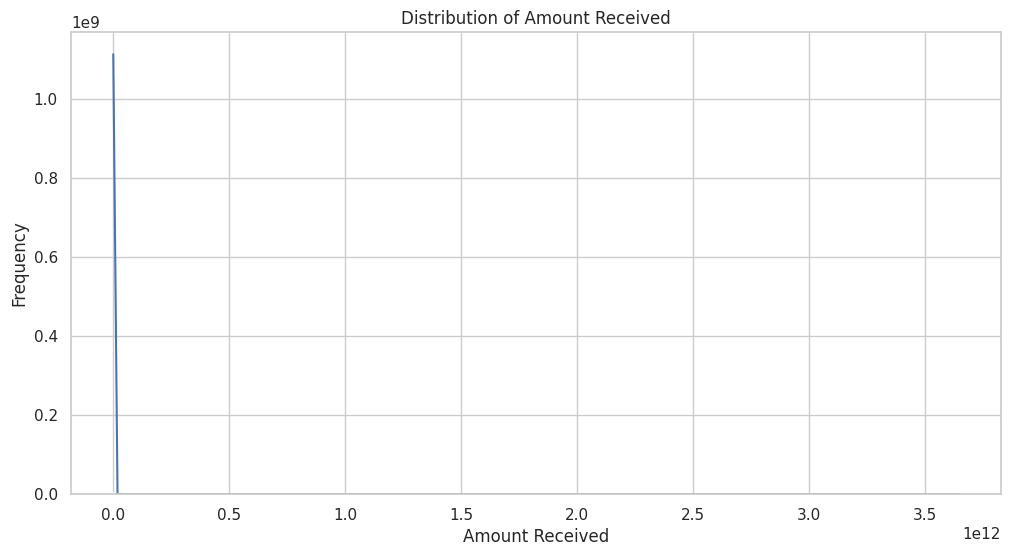

In [11]:
# Histogram of Amount Received
sns.histplot(df['Amount Received'], bins=100, kde=True)
plt.title('Distribution of Amount Received')
plt.xlabel('Amount Received')
plt.ylabel('Frequency')
plt.show()

Currency and Payment Format Analysis

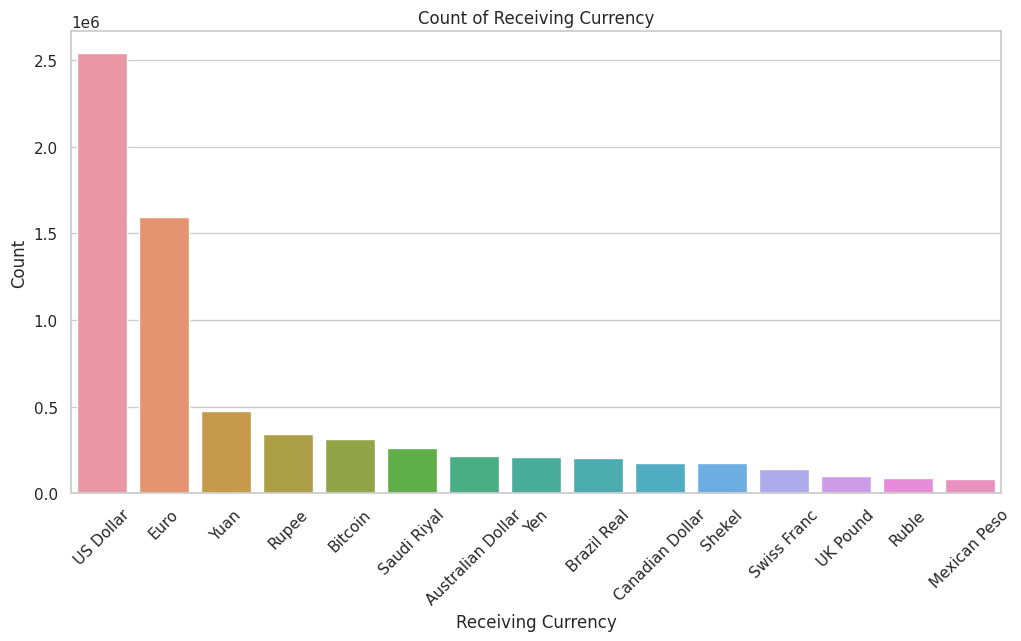

In [12]:
# Barplot for Receiving Currency counts
sns.countplot(data=df, x='Receiving Currency', order=df['Receiving Currency'].value_counts().index)
plt.title('Count of Receiving Currency')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

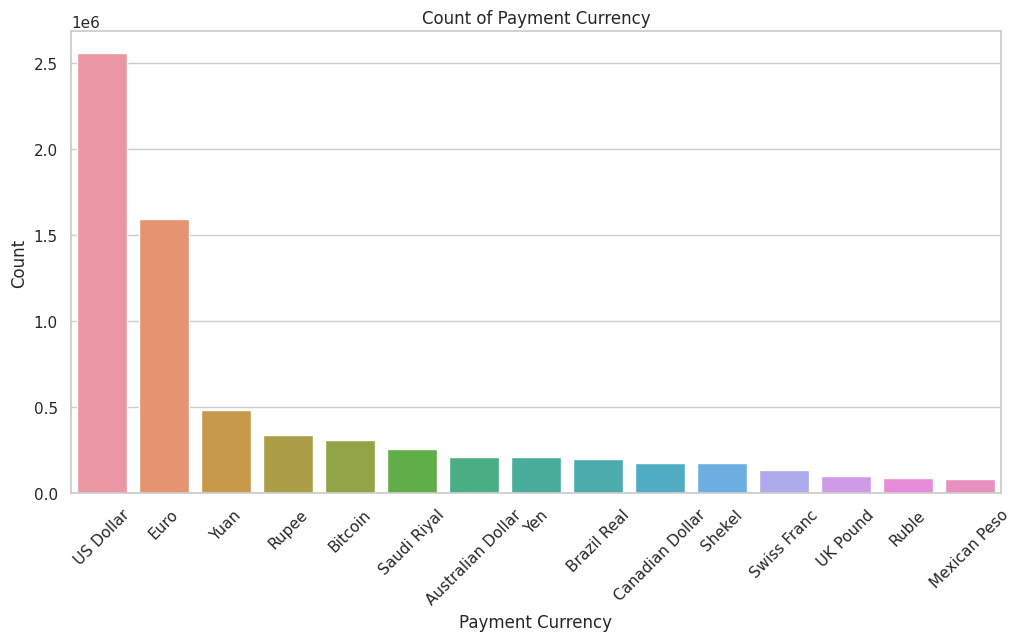

In [13]:
# Barplot for Payment Currency
sns.countplot(data=df, x='Payment Currency', order=df['Payment Currency'].value_counts().index)
plt.title('Count of Payment Currency')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

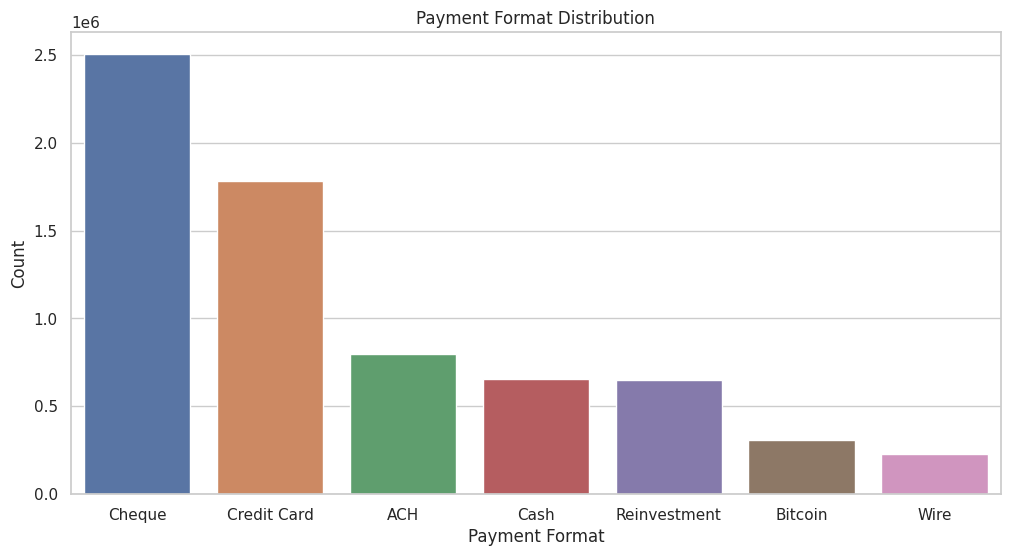

In [14]:
# Barplot for Payment Format
sns.countplot(data=df, x='Payment Format', order=df['Payment Format'].value_counts().index)
plt.title('Payment Format Distribution')
plt.ylabel('Count')
plt.show()

Laundering Transactions Overview

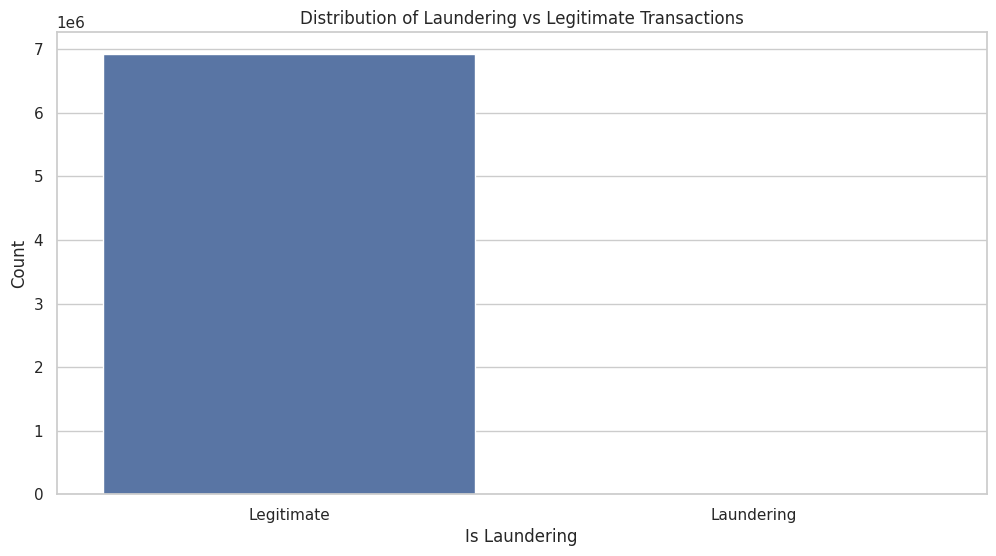

In [15]:
# Countplot for Is Laundering
sns.countplot(data=df, x='Is Laundering')
plt.title('Distribution of Laundering vs Legitimate Transactions')
plt.xticks([0,1], ['Legitimate', 'Laundering'])
plt.ylabel('Count')
plt.show()

In [16]:
# Proportion of laundering
laundering_proportion = df['Is Laundering'].mean()
print(f"Proportion of laundering transactions: {laundering_proportion:.4f}")

Proportion of laundering transactions: 0.0005


Time Series Plots

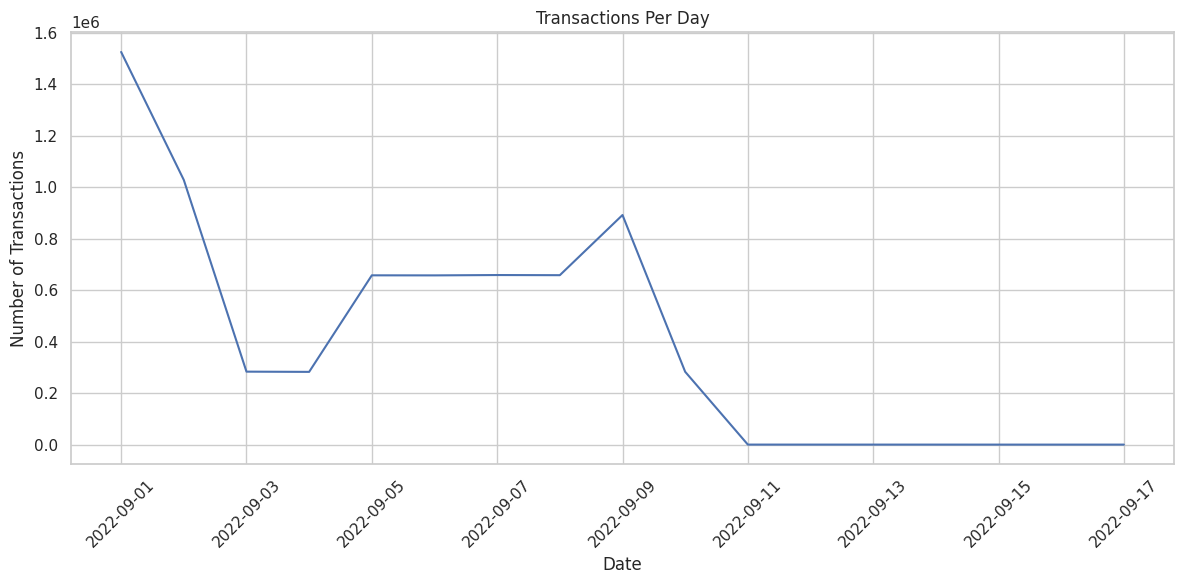

In [17]:
# Convert Timestamp to datetime 
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Number of transactions per day
df['date'] = df['Timestamp'].dt.date
tx_per_day = df.groupby('date').size()

plt.plot(tx_per_day.index, tx_per_day.values)
plt.title('Transactions Per Day')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

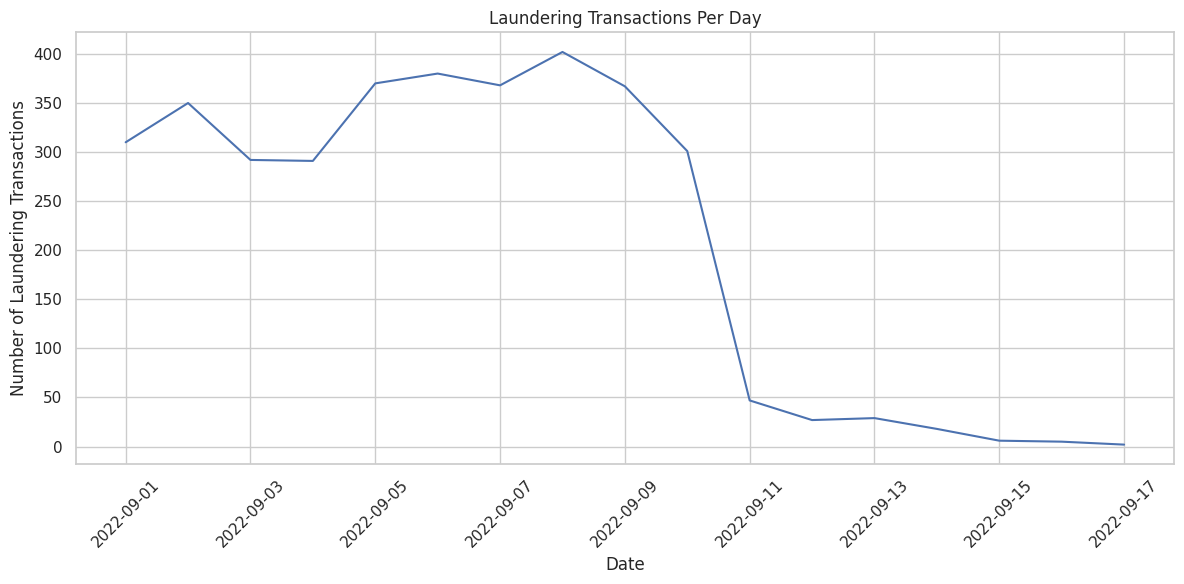

In [18]:
# Number of laundering transactions per day
laundering_per_day = df[df['Is Laundering'] == 1].groupby('date').size()
plt.plot(laundering_per_day.index, laundering_per_day.values)
plt.title('Laundering Transactions Per Day')
plt.xlabel('Date')
plt.ylabel('Number of Laundering Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Amounts by Currency

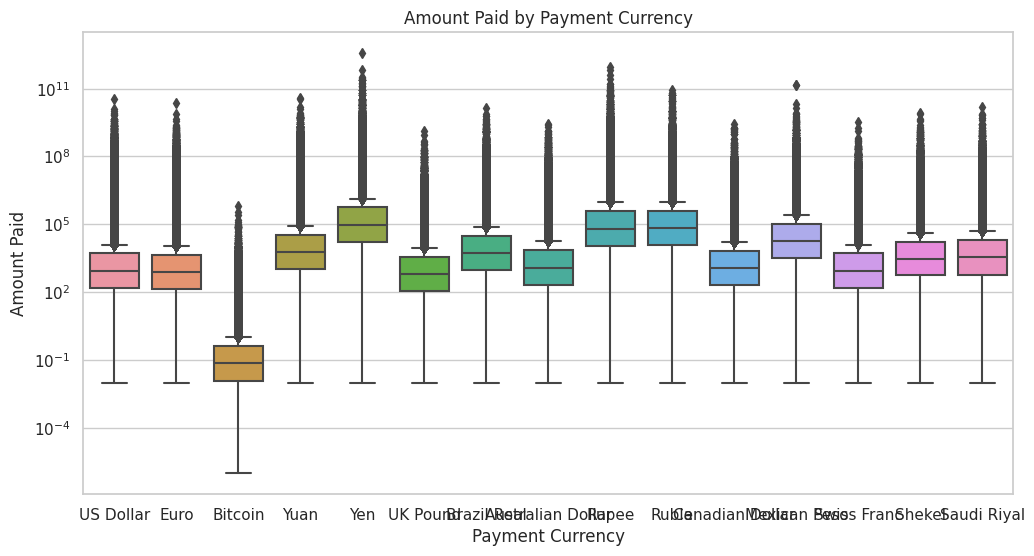

In [19]:
# Boxplot for Amount Paid by Payment Currency
sns.boxplot(x='Payment Currency', y='Amount Paid', data=df)
plt.title('Amount Paid by Payment Currency')
plt.yscale('log')
plt.show()

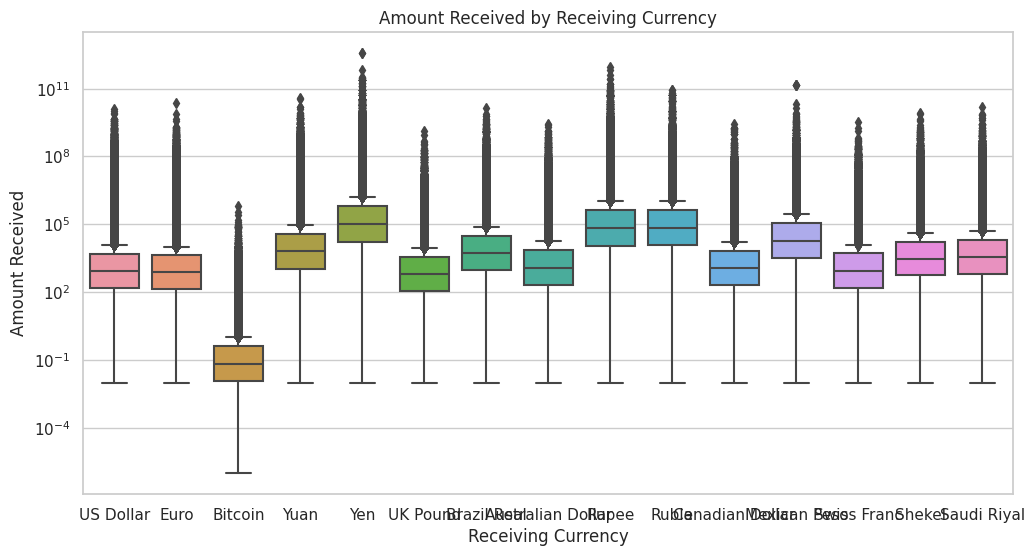

In [20]:
# Boxplot for Amount Received by Receiving Currency
sns.boxplot(x='Receiving Currency', y='Amount Received', data=df)
plt.title('Amount Received by Receiving Currency')
plt.yscale('log')
plt.show()

Amount Distribution by Laundering Flag

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


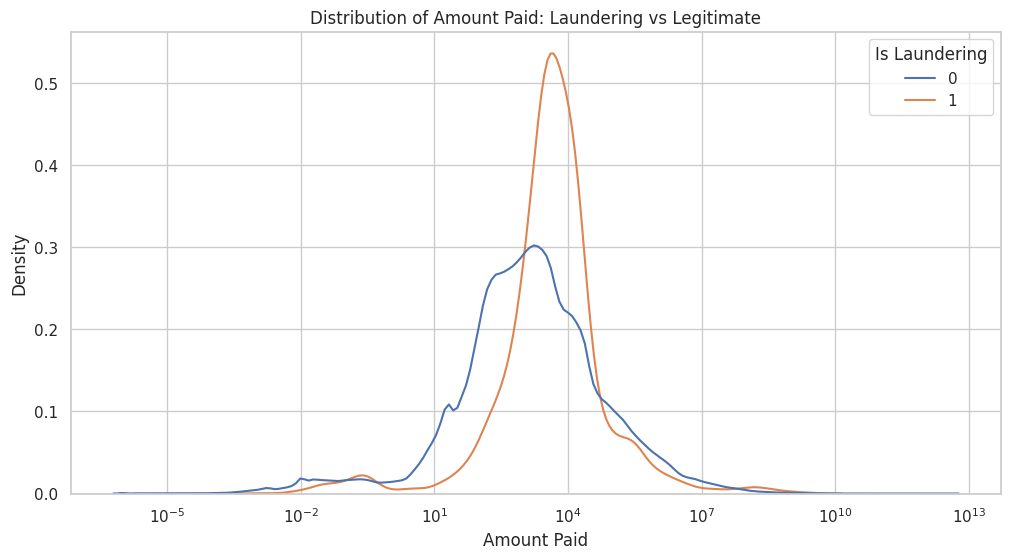

In [21]:
# KDE plot for Amount Paid split by Is Laundering
sns.kdeplot(data=df, x='Amount Paid', hue='Is Laundering', common_norm=False, log_scale=True)
plt.title('Distribution of Amount Paid: Laundering vs Legitimate')
plt.xlabel('Amount Paid')
plt.show()

Correlation Heatmap

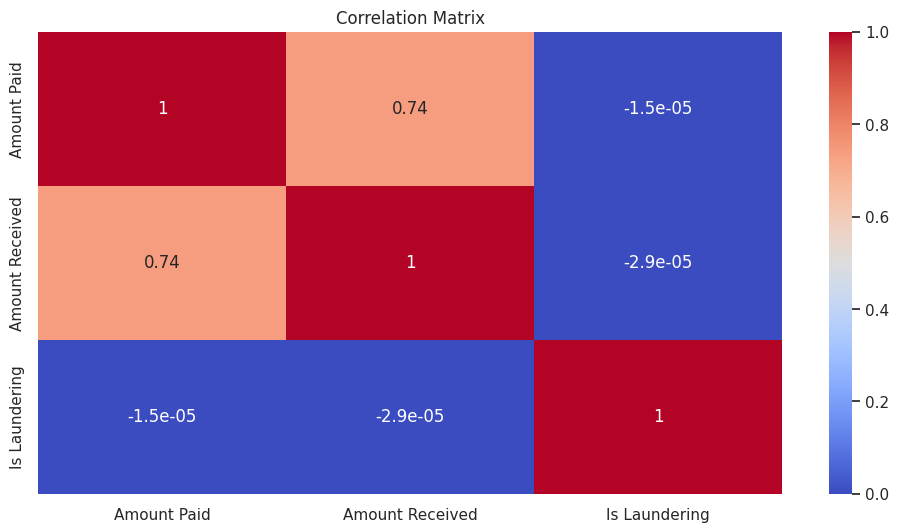

In [22]:
# Correlation matrix for numeric columns
corr = df[['Amount Paid', 'Amount Received', 'Is Laundering']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Top-Active Banks & Accounts

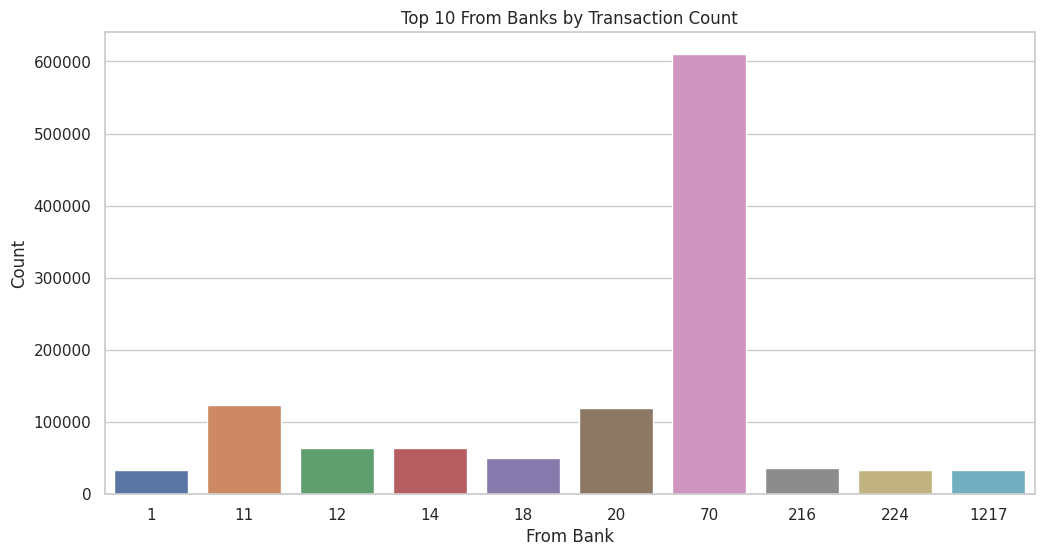

In [23]:
top_from_banks = df['From Bank'].value_counts().head(10)
sns.barplot(x=top_from_banks.index, y=top_from_banks.values)
plt.title('Top 10 From Banks by Transaction Count')
plt.ylabel('Count')
plt.xlabel('From Bank')
plt.show()

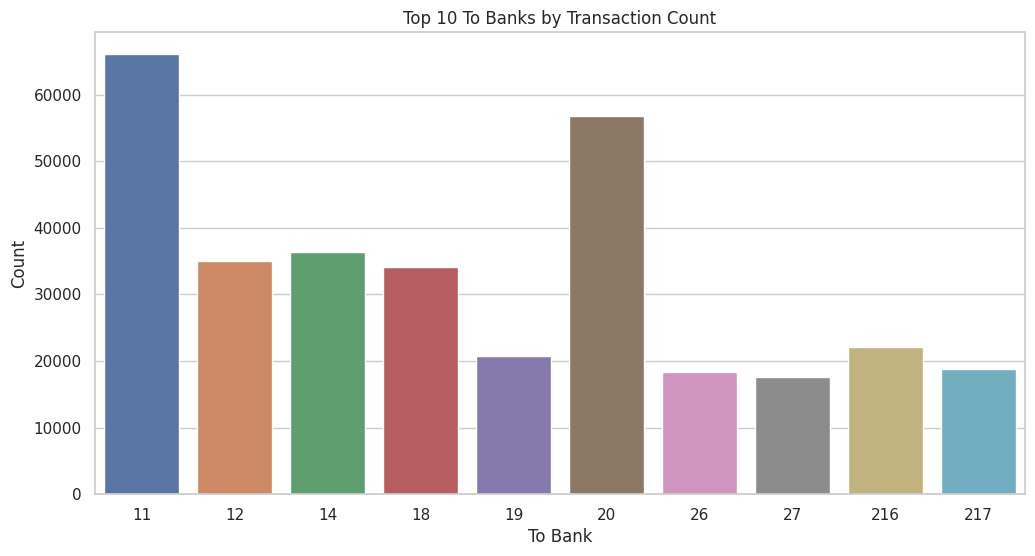

In [24]:
top_to_banks = df['To Bank'].value_counts().head(10)
sns.barplot(x=top_to_banks.index, y=top_to_banks.values)
plt.title('Top 10 To Banks by Transaction Count')
plt.ylabel('Count')
plt.xlabel('To Bank')
plt.show()